# CLASIFICACIÓN DE IMAGENES CON REDES NEURONALES CONVOLUCIONALES
# DATASET : CIFAR 10 (https://www.cs.toronto.edu/~kriz/cifar.html)

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train),(x_test,y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


# MOSTRAMOS UNA IMAGEN ALEATORIA

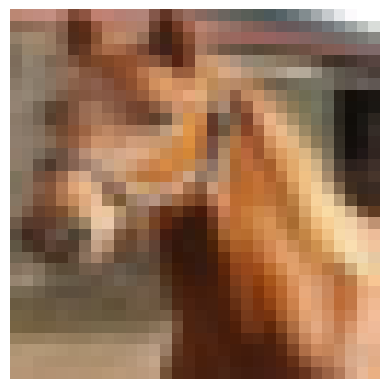

In [4]:
# Seleccionar un índice aleatorio
idx = np.random.randint(0, len(x_train))

# Mostrar la imagen
plt.imshow(x_train[idx])
plt.axis('off')  # Ocultar ejes
plt.show()

# NORMALIZAR VALORES Y ESCALAR

In [5]:
# Normalizar los valores de píxeles a [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convertir etiquetas a one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [6]:
class_names = ['avión', 'auto', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']

# CREAMOS EL MODELO DE RED CONVOLUCIONAL

In [7]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# COMPILAMOS EL MODELO

In [8]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [9]:
history = model.fit(x_train,y_train,epochs=3,batch_size=64,validation_data=(x_test,y_test))

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 140ms/step - accuracy: 0.2936 - loss: 1.8908 - val_accuracy: 0.5401 - val_loss: 1.2797
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 133ms/step - accuracy: 0.5192 - loss: 1.3438 - val_accuracy: 0.6308 - val_loss: 1.0518
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 133ms/step - accuracy: 0.6015 - loss: 1.1296 - val_accuracy: 0.6688 - val_loss: 0.9481


# EVALUAMOS EL MODELO

313/313 - 6s - 19ms/step - accuracy: 0.6688 - loss: 0.9481

Precisión en test: 66.88%


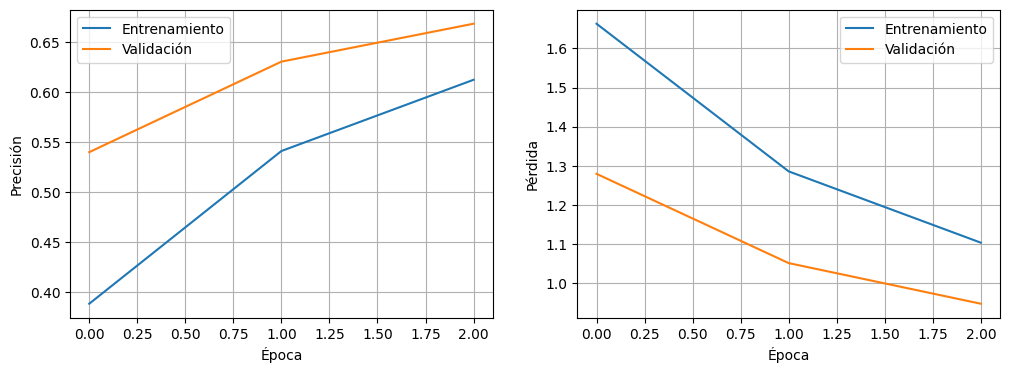

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nPrecisión en test: {test_acc * 100:.2f}%')

# 6. Graficar precisión y pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid()

plt.show()

# MOSTRAMOS ALGUNAS IMAGENES CON SUS PREDICCIONES

In [11]:
def mostrar_predicciones(model, x_test, y_test, class_names):
    plt.figure(figsize=(10,5))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        img = x_test[i]
        true_label = np.argmax(y_test[i])
        pred_label = np.argmax(model.predict(img.reshape(1, 32, 32, 3)))

        plt.imshow(img)
        plt.title(f'Real: {class_names[true_label]}\nPred: {class_names[pred_label]}', fontsize=10)
        plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


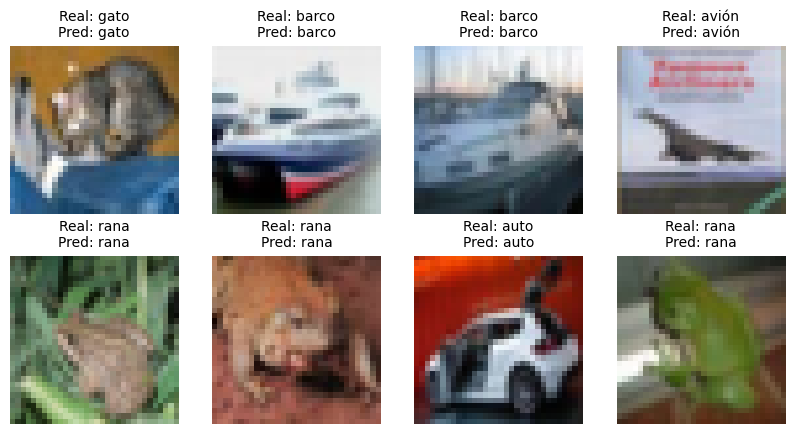

In [12]:
mostrar_predicciones(model, x_test, y_test, class_names)